11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape : (10000, 28, 28)


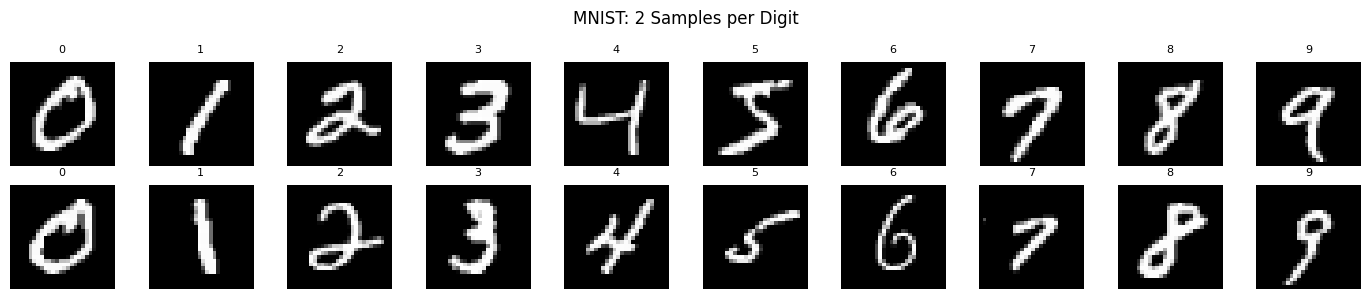

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8746 - loss: 0.4146 - val_accuracy: 0.9628 - val_loss: 0.1267
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9473 - loss: 0.1775 - val_accuracy: 0.9752 - val_loss: 0.0851
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9596 - loss: 0.1338 - val_accuracy: 0.9777 - val_loss: 0.0743
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9660 - loss: 0.1087 - val_accuracy: 0.9792 - val_loss: 0.0697
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9718 - loss: 0.0917 - val_accuracy: 0.9815 - val_loss: 0.0632
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9758 - loss: 0.0796 - val_accuracy: 0.9825 - val_loss: 0.0618
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9780 - loss: 0.0700 - val_accuracy: 0.9830 - val_loss: 0.0608
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9794 - loss: 0.0642 - val_acc

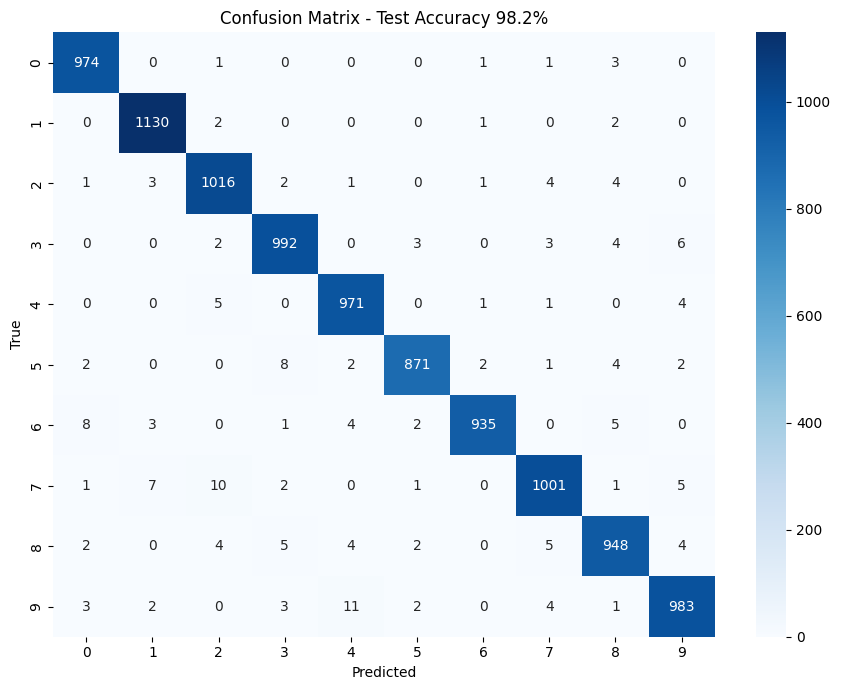


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


Misclassified: 179 out of 10000


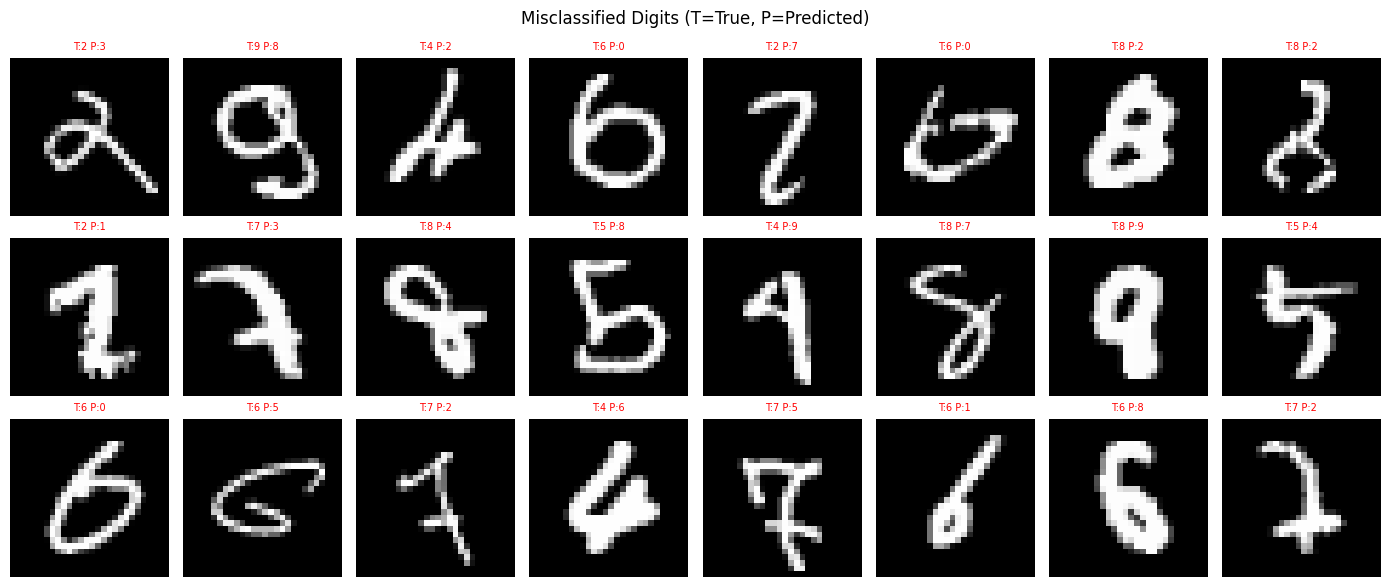


Architecture Comparison
Small / No Dropout                  Accuracy: 97.39%
Medium / Light Dropout              Accuracy: 97.97%
Large / Moderate Dropout            Accuracy: 98.22%


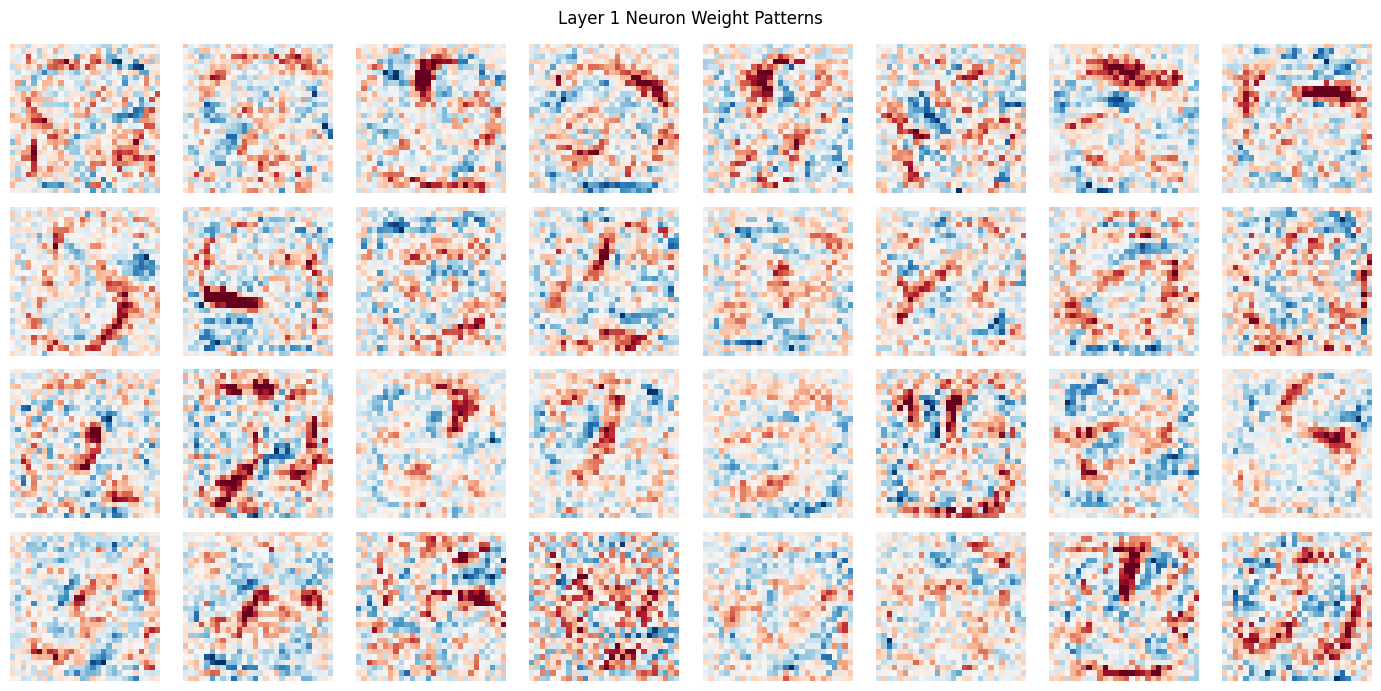

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)
X_train = X_train.reshape(-1, 784).astype("float32") / 255.0
X_test = X_test.reshape(-1, 784).astype("float32") / 255.0
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    for row, offset in enumerate([0, 1]):
        idx = np.where(y_train == digit)[0][offset]
        axes[row, digit].imshow(
            X_train[idx].reshape(28, 28),
            cmap="gray"
        )
        axes[row, digit].set_title(str(digit), fontsize=8)
        axes[row, digit].axis("off")
plt.suptitle("MNIST: 2 Samples per Digit")
plt.tight_layout()
plt.show()

def make_model(h1=256, h2=128, drop=0.3):

    model = keras.Sequential([
        keras.Input(shape=(784,)),

        layers.Dense(h1, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(h2, activation="relu"),
        layers.Dropout(drop),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
model = make_model()
model.summary()
early_stop = EarlyStopping(
    patience=5,
    restore_best_weights=True
)
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
loss, acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print(f"\nTest Accuracy: {acc * 100:.2f}%")
y_pred = np.argmax(
    model.predict(X_test),
    axis=1
)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title(
    f"Confusion Matrix - Test Accuracy {acc*100:.1f}%"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)
wrong = np.where(y_pred != y_test)[0]
print(
    f"\nMisclassified: {len(wrong)} "
    f"out of {len(y_test)}"
)
fig, axes = plt.subplots(
    3,
    8,
    figsize=(14, 6)
)
for i, ax in enumerate(axes.flat):
    if i < len(wrong):
        idx = wrong[i]
        ax.imshow(
            X_test[idx].reshape(28, 28),
            cmap="gray"
        )
        ax.set_title(
            f"T:{y_test[idx]} P:{y_pred[idx]}",
            color="red",
            fontsize=7
        )
    ax.axis("off")

plt.suptitle(
    "Misclassified Digits (T=True, P=Predicted)"
)

plt.tight_layout()
plt.show()
configs = [
    (64, 32, 0.0, "Small / No Dropout"),
    (128, 64, 0.2, "Medium / Light Dropout"),
    (256, 128, 0.3, "Large / Moderate Dropout")
]

print("\nArchitecture Comparison")

for h1, h2, dr, label in configs:

    m = make_model(h1, h2, dr)

    m.fit(
        X_train,
        y_train,
        epochs=15,
        batch_size=128,
        validation_split=0.1,
        verbose=0,
        callbacks=[
            EarlyStopping(
                patience=3,
                restore_best_weights=True
            )
        ]
    )

    _, accuracy = m.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    print(
        f"{label:35s} Accuracy: "
        f"{accuracy*100:.2f}%"
    )
weights = model.layers[0].get_weights()[0]

fig, axes = plt.subplots(
    4,
    8,
    figsize=(14, 7)
)

for i, ax in enumerate(axes.flat):

    w = weights[:, i].reshape(28, 28)

    ax.imshow(
        w,
        cmap="RdBu",
        vmin=-w.max(),
        vmax=w.max()
    )

    ax.axis("off")

plt.suptitle(
    "Layer 1 Neuron Weight Patterns"
)

plt.tight_layout()
plt.show()